# ELSA Depression Prediction
### MSc AI & Health — Group Assignment

**Goal:** Use Wave 6 features to predict whether a participant has depression at Wave 7.

**Target variable:** `hepsyde` — *Psychiatric problem: depression* (0 = not mentioned, 1 = mentioned)

**Models:** Random Forest + XGBoost (compared side by side)

## Cell 1 — Install & Import Libraries

In [1]:
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from lightgbm import LGBMClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Libraries loaded successfully.


## Cell 2 — Load the Data

In [2]:
w6 = pd.read_stata('./ELSA_Dataset/ELSA_Raw/wave_6_elsa_data_v2.dta', convert_categoricals=False)
w7 = pd.read_stata('./ELSA_Dataset/ELSA_Raw/wave_7_elsa_data.dta', convert_categoricals=False)

print(f'Wave 6: {w6.shape[0]:,} participants, {w6.shape[1]} columns')
print(f'Wave 7: {w7.shape[0]:,} participants, {w7.shape[1]} columns')

print('\nWave 6 columns:', list(w6.columns))
print('\nWave 7 columns:', list(w7.columns))

Wave 6: 10,601 participants, 6189 columns
Wave 7: 9,666 participants, 6350 columns

Wave 6 columns: ['idauniq', 'idahhw6', 'perid', 'samptyp', 'w6indout', 'W6hhout', 'couple', 'cpid', 'chinhh', 'chouthh', 'gcinhh', 'mainhh', 'painhh', 'HHTot', 'WhoSo1', 'WhoSo2', 'WhoSo3', 'WhoSo4', 'WhoSo5', 'concur', 'ordcon', 'futype', 'hhresp', 'DhSameH', 'DhSex', 'DhDoBC', 'DhWork', 'DhR', 'DhR2', 'DhR3', 'DhR4', 'DhR5', 'DhR6', 'DhR7', 'DhR8', 'DhR9', 'DhR10', 'DhR11', 'DhR12', 'DhR13', 'DhR14', 'DhR15', 'DhR16', 'DhPA', 'DhPB', 'DhC', 'DhCS', 'DhCAg', 'DHCR01', 'DHCR02', 'DHCR03', 'DHCR04', 'DHCR05', 'DHCR06', 'DHCR07', 'DHCR08', 'DHCR09', 'DHCR10', 'DHCR11', 'DHCR12', 'DHCR13', 'DHCR14', 'DHCR15', 'DHCR16', 'DhPA2', 'DhPB2', 'DhC2', 'DhCS2', 'DHDoBC2', 'DhCAg2', 'DHCR17', 'DHCR18', 'DHCR19', 'DHCR20', 'DHCR21', 'DHCR22', 'DHCR23', 'DHCR24', 'DHCR25', 'DHCR26', 'DHCR27', 'DHCR28', 'DHCR29', 'DHCR30', 'DHCR31', 'DHCR32', 'DhPA3', 'DhPB3', 'DhC3', 'DhCS3', 'DHDoBC3', 'DhCAg3', 'DHCR33', 'DHCR34', 

## CES-D-8 Score Computation
Compute binary scored items and total score for both waves before any further processing.

In [3]:
# ----- CES-D-8 Definitions -----
# PScedD (Happy) and PScedF (Enjoyed life) are POSITIVE affect items, reverse scored
# All items encoded: 1 = Yes, 2 = No
# Normal items:  Yes(1) = symptom → binary 1
# Reverse items: Yes(1) = no symptom → binary 0

PSCED_COLS = ['PScedA','PScedB','PScedC','PScedD','PScedE','PScedF','PScedG','PScedH']
REVERSE_ITEMS = ['PScedD', 'PScedF']

ITEM_LABELS = {
    'PScedA': 'Depressed',
    'PScedB': 'Effortful',
    'PScedC': 'Restless sleep',
    'PScedD': 'Happy (R)',
    'PScedE': 'Lonely',
    'PScedF': 'Enjoyed life (R)',
    'PScedG': 'Sad',
    'PScedH': 'Could not get going',
}

def compute_cesd(df):
    """Add binary CES-D items and total score to a wave dataframe."""
    d = df.copy()
    for col in PSCED_COLS:
        d[col] = d[col].replace([-1, -8, -9], np.nan)
        bin_col = col + '_bin'
        if col in REVERSE_ITEMS:
            d[bin_col] = d[col].map({1: 0, 2: 1})
        else:
            d[bin_col] = d[col].map({1: 1, 2: 0})
    bin_cols = [c + '_bin' for c in PSCED_COLS]
    d['cesd_total'] = d[bin_cols].sum(axis=1, min_count=1)
    return d, bin_cols

w6, bin_cols = compute_cesd(w6)
w7, _        = compute_cesd(w7)

print(f'CES-D-8 scores computed.')
print(f'Wave 6 mean CES-D total: {w6["cesd_total"].mean():.2f}')
print(f'Wave 7 mean CES-D total: {w7["cesd_total"].mean():.2f}')


CES-D-8 scores computed.
Wave 6 mean CES-D total: 1.36
Wave 7 mean CES-D total: 1.36


## Cell 3 — Build the Target Variable (Wave 7 Depression)

`hepsyde` = 1 means the participant mentioned depression as a psychiatric problem at Wave 7.  
We treat this as our binary prediction target.

In [4]:
# ELSA missing codes — only -8 and -9 are TRUE missing for hepsyde
# -1 = 'Not applicable' = respondent not asked because no psychiatric history implied
# This expands our valid sample from ~1,000 to ~9,600 participants

w7_target = w7[['idauniq', 'hepsyde']].copy()
w7_target['hepsyde'] = w7_target['hepsyde'].replace([-8, -9], float('nan'))  # true missing only
w7_target['hepsyde'] = w7_target['hepsyde'].replace(-1, 0)                   # not applicable = not depressed
w7_target = w7_target.dropna(subset=['hepsyde'])
w7_target['depressed_w7'] = w7_target['hepsyde'].astype(int)

print(f'Wave 7 participants with valid depression label: {len(w7_target):,}')
print(f"\nClass balance:")
print(f"  Depressed (hepsyde=1): {w7_target['depressed_w7'].sum()} ({w7_target['depressed_w7'].mean()*100:.1f}%)")
print(f"  Not depressed (hepsyde=0): {(w7_target['depressed_w7']==0).sum()} ({(1-w7_target['depressed_w7'].mean())*100:.1f}%)")


Wave 7 participants with valid depression label: 9,638

Class balance:
  Depressed (hepsyde=1): 692 (7.2%)
  Not depressed (hepsyde=0): 8946 (92.8%)


## Cell 4 — Select Features from Wave 6

We use Wave 6 data to predict Wave 7 outcomes, this is a **longitudinal prediction** setup.

Feature categories:
- **Sociodemographic:** sex, marital status, education
- **Financial:** expectations, gross income, stability
- **Physical health:** self-rated health, illness, pain, smoking, activity
- **Prior mental health:** hepsyde, hepsyan etc. from Wave 6 (strongest predictors)

In [5]:
def recode_marital(val):
    if val in [2, 3, 4, 8, 11]:
        return 'Partnered'
    elif val == 1:
        return 'Single'
    elif val in [5, 6, 9]:
        return 'Separated/Divorced'
    elif val in [7, 10]:
        return 'Widowed'
    else:
        return np.nan

# Create 4 binary marital indicator columns on w6 (NaN where DiMar is invalid)
_marital = w6['DiMar'].apply(recode_marital)
for col, label in [
    ('marital_Partnered',   'Partnered'),
    ('marital_Single',      'Single'),
    ('marital_SepDivorced', 'Separated/Divorced'),
    ('marital_Widowed',     'Widowed'),
]:
    w6[col] = np.where(_marital.isna(), np.nan, (_marital == label).astype(float))

FEATURE_COLS = [
    # Sociodemographic
    'DiSex',
    'marital_Partnered', 'marital_Single', 'marital_SepDivorced', 'marital_Widowed',
    'DiMaedu',
    'ExRSLF',
    'Iafcon',
    'WpWlyy',

    # Physical health
    'Hehelf',    # Self-rated health — -1→NaN, -8/-9→NaN
    'Heill',     # Long-standing illness — -8/-9→NaN only
    'Helim',     # Limits activities — -1→2 (no illness = not limited)
    'HePain',    # Pain — -1→NaN, -8/-9→NaN
    'HeSmk',     # Smoking — -1→3 (never smoked = new category)
    'HeActa',    # Vigorous activity — -8/-9→NaN only
    'HeActb',    # Moderate activity — -8/-9→NaN only
    'HeActc',    # Mild activity — -9→NaN only

    # CES-D-8 binary items + total (computed in Cell 2b)
    'PScedA_bin', 'PScedB_bin', 'PScedC_bin', 'PScedD_bin',
    'PScedE_bin', 'PScedF_bin', 'PScedG_bin', 'PScedH_bin',
    'cesd_total'
]

w6_features = w6[['idauniq'] + FEATURE_COLS].copy()

# Apply per-variable rules
TRUE_MISSING = [-8, -9]

# Variables where -1 = genuinely missing/routing
for col in ['Hehelf', 'HePain', 'ExRSLF', 'Iafcon']:
    w6_features[col] = w6_features[col].replace([-1] + TRUE_MISSING, float('nan'))

# Variables where only -8/-9 are missing
for col in ['DiSex', 'DiMaedu', 'Heill', 'HeActa', 'HeActb', 'HeActc', 'WpWlyy']:
    w6_features[col] = w6_features[col].replace(TRUE_MISSING, float('nan'))

# Helim: -1 = not applicable because no illness → treat as 2 (not limited)
w6_features['Helim'] = w6_features['Helim'].replace(-1, 2).replace(TRUE_MISSING, float('nan'))

# HeSmk: -1 = not applicable = never smoked → treat as 3 (new category: never)
w6_features['HeSmk'] = w6_features['HeSmk'].replace(-1, 3).replace(TRUE_MISSING, float('nan'))

# CES-D bins already handled by compute_cesd()
for col in ['PScedA_bin','PScedB_bin','PScedC_bin','PScedD_bin',
            'PScedE_bin','PScedF_bin','PScedG_bin','PScedH_bin','cesd_total']:
    w6_features[col] = w6_features[col]  # already clean from compute_cesd

print(f'Wave 6 features extracted: {len(FEATURE_COLS)} features')
print(f'\nMissing data summary (% missing):')
missing_pct = (w6_features[FEATURE_COLS].isnull().sum() / len(w6_features) * 100).round(1)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct.to_string() if len(missing_pct) > 0 else 'No missing values!')

Wave 6 features extracted: 26 features

Missing data summary (% missing):
DiMaedu       9.7
ExRSLF        8.4
Iafcon        7.0
WpWlyy        0.4
Hehelf        5.9
Heill         0.1
HePain        5.9
PScedA_bin    6.5
PScedB_bin    6.5
PScedC_bin    6.4
PScedD_bin    6.6
PScedE_bin    6.5
PScedF_bin    6.7
PScedG_bin    6.6
PScedH_bin    6.5
cesd_total    6.4


## Cell 5 — Merge Waves & Final Dataset

In [6]:
# Keep only participants present in both waves with a valid target
df = pd.merge(
    w6_features,
    w7_target[['idauniq', 'depressed_w7']],
    on='idauniq',
    how='inner'
)

print(f'Final dataset: {len(df):,} participants')
print(f'Depressed at Wave 7: {df["depressed_w7"].sum()} ({df["depressed_w7"].mean()*100:.1f}%)')
print(f'Not depressed: {(df["depressed_w7"]==0).sum()} ({(1-df["depressed_w7"].mean())*100:.1f}%)')

# Separate features and target
X = df[FEATURE_COLS]
y = df['depressed_w7']

print(f'\nFeature matrix shape: {X.shape}')

Final dataset: 8,838 participants
Depressed at Wave 7: 628 (7.1%)
Not depressed: 8210 (92.9%)

Feature matrix shape: (8838, 26)


## CES-D-8 Analysis
How Wave 6 CES-D scores relate to depression at Wave 7.

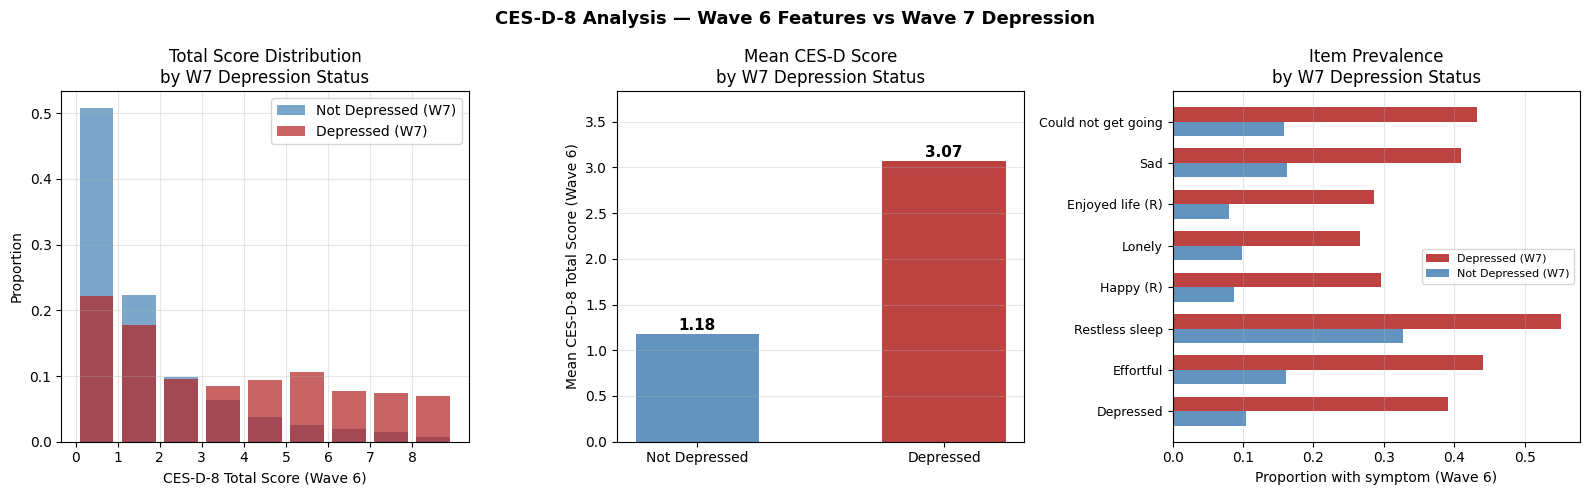

Saved: cesd_analysis.png


In [7]:
import matplotlib.patches as mpatches

# Use merged df (created in Cell 5) for analysis
dep   = df[df['depressed_w7'] == 1]['cesd_total']
nodep = df[df['depressed_w7'] == 0]['cesd_total']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('CES-D-8 Analysis — Wave 6 Features vs Wave 7 Depression', fontsize=13, fontweight='bold')

# Plot 1: Score distribution by depression status
axes[0].hist(nodep, bins=range(0,10), alpha=0.7, color='steelblue', label='Not Depressed (W7)', density=True, rwidth=0.8)
axes[0].hist(dep,   bins=range(0,10), alpha=0.7, color='firebrick', label='Depressed (W7)',     density=True, rwidth=0.8)
axes[0].set_xlabel('CES-D-8 Total Score (Wave 6)')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Total Score Distribution\nby W7 Depression Status')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_xticks(range(0,9))

# Plot 2: Mean score per group
means = df.groupby('depressed_w7')['cesd_total'].mean()
bars = axes[1].bar(['Not Depressed', 'Depressed'], means.values,
                   color=['steelblue','firebrick'], alpha=0.85, width=0.5)
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean CES-D-8 Total Score (Wave 6)')
axes[1].set_title('Mean CES-D Score\nby W7 Depression Status')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_ylim(0, max(means.values)*1.25)

# Plot 3: Item-level symptom prevalence
item_rates_dep   = df[df['depressed_w7']==1][bin_cols].mean()
item_rates_nodep = df[df['depressed_w7']==0][bin_cols].mean()
short_labels = [ITEM_LABELS[c] for c in PSCED_COLS]
x = np.arange(len(PSCED_COLS)); bw = 0.35
axes[2].barh(x+bw/2, item_rates_dep.values,   bw, color='firebrick', alpha=0.85, label='Depressed (W7)')
axes[2].barh(x-bw/2, item_rates_nodep.values, bw, color='steelblue', alpha=0.85, label='Not Depressed (W7)')
axes[2].set_yticks(x); axes[2].set_yticklabels(short_labels, fontsize=9)
axes[2].set_xlabel('Proportion with symptom (Wave 6)')
axes[2].set_title('Item Prevalence\nby W7 Depression Status')
axes[2].legend(fontsize=8); axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cesd_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cesd_analysis.png')


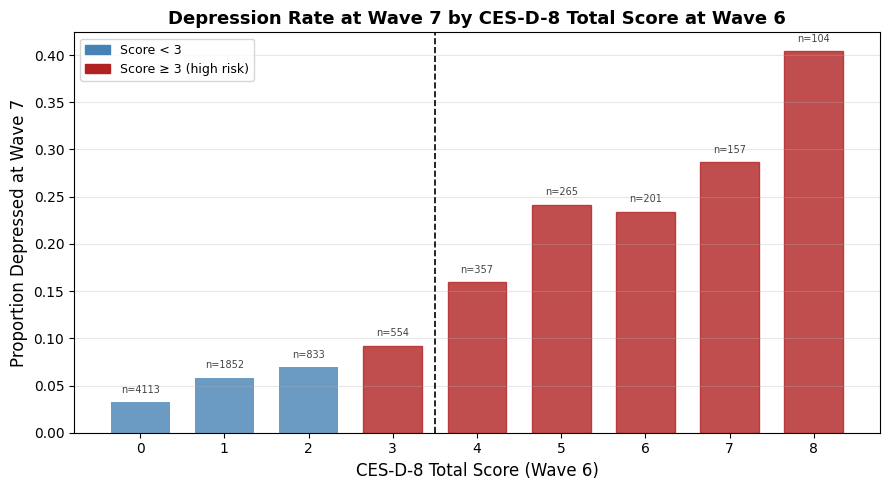

Saved: cesd_depression_rate.png


In [8]:
score_dep_rate = df.groupby('cesd_total')['depressed_w7'].agg(['mean','count']).reset_index()
score_dep_rate.columns = ['cesd_total','dep_rate','count']

fig2, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(score_dep_rate['cesd_total'], score_dep_rate['dep_rate'],
              color='steelblue', alpha=0.8, width=0.7)
for bar, score in zip(bars, score_dep_rate['cesd_total']):
    if score >= 3:
        bar.set_color('firebrick')
for bar, row in zip(bars, score_dep_rate.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'n={row.count}', ha='center', fontsize=7, color='#444')
ax.axvline(x=3.5, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('CES-D-8 Total Score (Wave 6)', fontsize=12)
ax.set_ylabel('Proportion Depressed at Wave 7', fontsize=12)
ax.set_title('Depression Rate at Wave 7 by CES-D-8 Total Score at Wave 6', fontsize=13, fontweight='bold')
ax.set_xticks(range(0,9))
blue_p = mpatches.Patch(color='steelblue', label='Score < 3')
red_p  = mpatches.Patch(color='firebrick', label='Score ≥ 3 (high risk)')
ax.legend(handles=[blue_p, red_p], fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cesd_depression_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cesd_depression_rate.png')


In [9]:
summary_rows = []
for col, bc in zip(PSCED_COLS, bin_cols):
    r_dep   = df[df['depressed_w7']==1][bc].mean()
    r_nodep = df[df['depressed_w7']==0][bc].mean()
    summary_rows.append({
        'Item':               col,
        'Label':              ITEM_LABELS[col],
        'Not Depressed (W7)': f'{r_nodep:.1%}',
        'Depressed (W7)':     f'{r_dep:.1%}',
        'Difference':         f'{r_dep - r_nodep:+.1%}',
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print(f'\nMean CES-D total — Not Depressed: {nodep.mean():.2f}')
print(f'Mean CES-D total — Depressed:     {dep.mean():.2f}')
print(f'Difference:                       +{dep.mean()-nodep.mean():.2f}')
summary_df


  Item               Label Not Depressed (W7) Depressed (W7) Difference
PScedA           Depressed              10.4%          39.2%     +28.8%
PScedB           Effortful              16.1%          44.1%     +28.0%
PScedC      Restless sleep              32.7%          55.1%     +22.4%
PScedD           Happy (R)               8.7%          29.6%     +20.8%
PScedE              Lonely               9.9%          26.6%     +16.7%
PScedF    Enjoyed life (R)               8.0%          28.7%     +20.7%
PScedG                 Sad              16.3%          41.0%     +24.8%
PScedH Could not get going              15.8%          43.3%     +27.5%

Mean CES-D total — Not Depressed: 1.18
Mean CES-D total — Depressed:     3.07
Difference:                       +1.89


,Item,Label,Not Depressed (W7),Depressed (W7),Difference
0,PScedA,Depressed,10.4%,39.2%,+28.8%
1,PScedB,Effortful,16.1%,44.1%,+28.0%
2,PScedC,Restless sleep,32.7%,55.1%,+22.4%
3,PScedD,Happy (R),8.7%,29.6%,+20.8%
4,PScedE,Lonely,9.9%,26.6%,+16.7%
5,PScedF,Enjoyed life (R),8.0%,28.7%,+20.7%
6,PScedG,Sad,16.3%,41.0%,+24.8%
7,PScedH,Could not get going,15.8%,43.3%,+27.5%


## Cell 6 — Train / Test Split

In [10]:
# Stratified split preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,
    stratify=y
)

print(f'Training set: {len(X_train):,} participants ({y_train.mean()*100:.1f}% depressed)')
print(f'Test set:     {len(X_test):,} participants ({y_test.mean()*100:.1f}% depressed)')

Training set: 7,070 participants (7.1% depressed)
Test set:     1,768 participants (7.1% depressed)


## Cell 7 — Train Random Forest

Key settings:
- `n_estimators=300` — 300 trees in the forest
- `class_weight='balanced'` — automatically handles class imbalance
- `SimpleImputer` — fills missing values with the median before training

In [11]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)

print('Random Forest trained.')
print(f'ROC-AUC on test set: {rf_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Not Depressed', 'Depressed']))

Random Forest trained.
ROC-AUC on test set: 0.726

Classification Report:
               precision    recall  f1-score   support

Not Depressed       0.95      0.94      0.94      1642
    Depressed       0.30      0.32      0.31       126

     accuracy                           0.90      1768
    macro avg       0.62      0.63      0.63      1768
 weighted avg       0.90      0.90      0.90      1768



## Cell 8 — Train XGBoost

XGBoost is a **gradient boosting** model — instead of building trees independently (like Random Forest), it builds each tree to correct the errors of the previous one. Often more accurate, but slightly harder to tune.

In [12]:
# Calculate scale_pos_weight to handle class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'Class imbalance ratio (scale_pos_weight): {scale:.2f}')

xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,   # handles class imbalance
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_auc  = roc_auc_score(y_test, xgb_prob)

print('\nXGBoost trained.')
print(f'ROC-AUC on test set: {xgb_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['Not Depressed', 'Depressed']))

Class imbalance ratio (scale_pos_weight): 13.08

XGBoost trained.
ROC-AUC on test set: 0.711

Classification Report:
               precision    recall  f1-score   support

Not Depressed       0.95      0.80      0.87      1642
    Depressed       0.15      0.45      0.23       126

     accuracy                           0.78      1768
    macro avg       0.55      0.63      0.55      1768
 weighted avg       0.89      0.78      0.83      1768



## Cell 9 — Train LightGBM

In [13]:
# ----- LightGBM -----
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

lgbm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,   # same class imbalance correction as XGBoost
        random_state=42,
        n_jobs=-1,
        verbose=-1                # suppress training output
    ))
])

lgbm_pipeline.fit(X_train, y_train)

lgbm_pred = lgbm_pipeline.predict(X_test)
lgbm_prob = lgbm_pipeline.predict_proba(X_test)[:, 1]
lgbm_auc  = roc_auc_score(y_test, lgbm_prob)

print('LightGBM trained.')
print(f'ROC-AUC on test set: {lgbm_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, lgbm_pred, target_names=['Not Depressed', 'Depressed']))

LightGBM trained.
ROC-AUC on test set: 0.707

Classification Report:
               precision    recall  f1-score   support

Not Depressed       0.95      0.81      0.87      1642
    Depressed       0.15      0.46      0.23       126

     accuracy                           0.78      1768
    macro avg       0.55      0.63      0.55      1768
 weighted avg       0.89      0.78      0.83      1768



## Cell 10 — Cross Validation (More Robust Evaluation)

A single train/test split can be lucky or unlucky. 5-fold cross-validation gives a more reliable estimate of true model performance.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv  = cross_val_score(rf_pipeline,  X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb_cv = cross_val_score(xgb_pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
lgbm_cv = cross_val_score(lgbm_pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('5-Fold Cross-Validation AUC:')
print(f'  Random Forest: {rf_cv.mean():.3f}  (+/- {rf_cv.std():.3f})')
print(f'  XGBoost:       {xgb_cv.mean():.3f}  (+/- {xgb_cv.std():.3f})')
print(f'  LightGBM:      {lgbm_cv.mean():.3f}  (+/- {lgbm_cv.std():.3f})')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


5-Fold Cross-Validation AUC:
  Random Forest: 0.726  (+/- 0.016)
  XGBoost:       0.703  (+/- 0.016)
  LightGBM:      0.701  (+/- 0.019)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Cell 11 — Plot Results: Confusion Matrices & ROC Curves

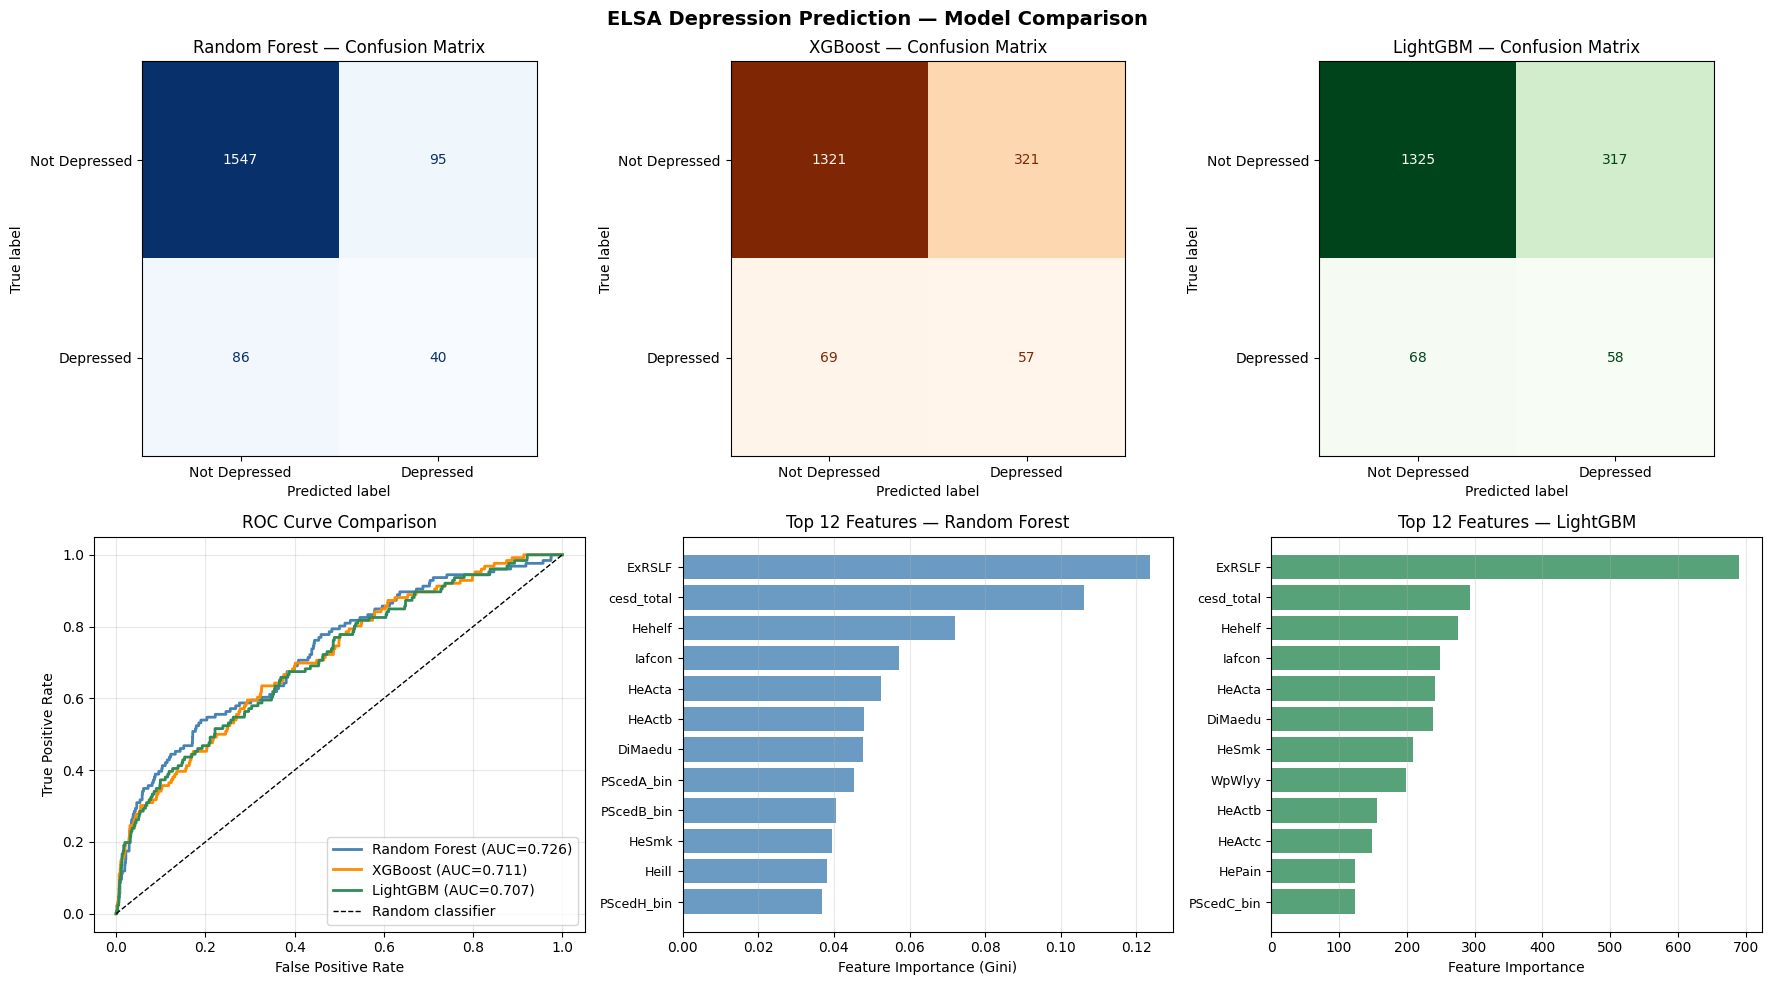

Plot saved as elsa_results.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ELSA Depression Prediction — Model Comparison', fontsize=14, fontweight='bold')

# --- Confusion Matrix: Random Forest ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pred),
    display_labels=['Not Depressed', 'Depressed']
).plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Random Forest — Confusion Matrix')

# --- Confusion Matrix: XGBoost ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgb_pred),
    display_labels=['Not Depressed', 'Depressed']
).plot(ax=axes[0, 1], colorbar=False, cmap='Oranges')
axes[0, 1].set_title('XGBoost — Confusion Matrix')

# --- Confusion Matrix: LightGBM ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, lgbm_pred),
    display_labels=['Not Depressed', 'Depressed']
).plot(ax=axes[0, 2], colorbar=False, cmap='Greens')
axes[0, 2].set_title('LightGBM — Confusion Matrix')

# --- ROC Curve: All three ---
for prob, label, color, auc in [
    (rf_prob,   'Random Forest', 'steelblue',  rf_auc),
    (xgb_prob,  'XGBoost',       'darkorange', xgb_auc),
    (lgbm_prob, 'LightGBM',      'seagreen',   lgbm_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1, 0].plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.3f})', color=color)
axes[1, 0].plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Feature Importance: Random Forest ---
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:12]
axes[1, 1].barh(
    range(len(indices)),
    importances[indices][::-1],
    color='steelblue', alpha=0.8
)
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels([FEATURE_COLS[i] for i in indices][::-1], fontsize=9)
axes[1, 1].set_xlabel('Feature Importance (Gini)')
axes[1, 1].set_title('Top 12 Features — Random Forest')
axes[1, 1].grid(True, axis='x', alpha=0.3)

# --- Feature Importance: LightGBM ---
lgbm_model = lgbm_pipeline.named_steps['model']
lgbm_importances = lgbm_model.feature_importances_
lgbm_indices = np.argsort(lgbm_importances)[::-1][:12]
axes[1, 2].barh(
    range(len(lgbm_indices)),
    lgbm_importances[lgbm_indices][::-1],
    color='seagreen', alpha=0.8
)
axes[1, 2].set_yticks(range(len(lgbm_indices)))
axes[1, 2].set_yticklabels([FEATURE_COLS[i] for i in lgbm_indices][::-1], fontsize=9)
axes[1, 2].set_xlabel('Feature Importance')
axes[1, 2].set_title('Top 12 Features — LightGBM')
axes[1, 2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('elsa_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as elsa_results.png')

## Cell 12 — Feature Importance: XGBoost

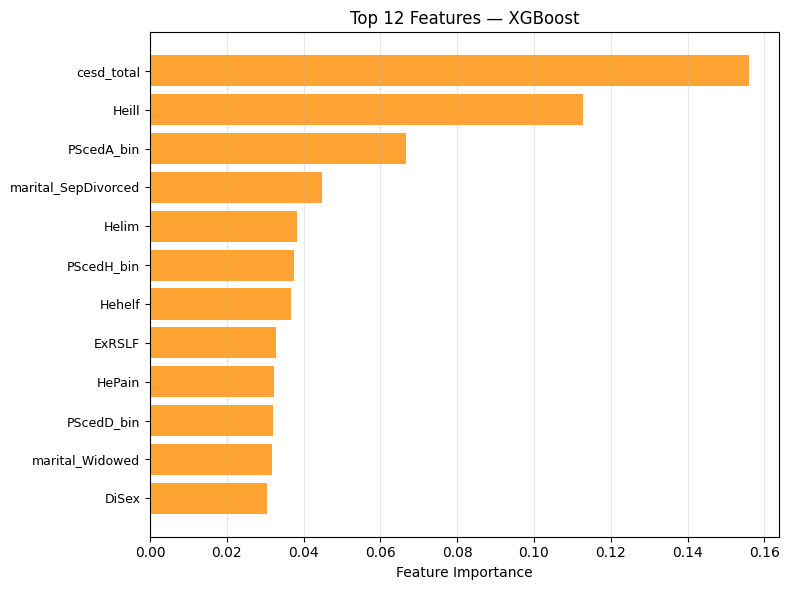

In [16]:
xgb_model = xgb_pipeline.named_steps['model']
xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1][:12]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    range(len(xgb_indices)),
    xgb_importances[xgb_indices][::-1],
    color='darkorange', alpha=0.8
)
ax.set_yticks(range(len(xgb_indices)))
ax.set_yticklabels([FEATURE_COLS[i] for i in xgb_indices][::-1], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 12 Features — XGBoost')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('elsa_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13 — Summary Table

In [17]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Model':     ['Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy':  [accuracy_score(y_test, rf_pred),   accuracy_score(y_test, xgb_pred),  accuracy_score(y_test, lgbm_pred)],
    'Precision': [precision_score(y_test, rf_pred),  precision_score(y_test, xgb_pred), precision_score(y_test, lgbm_pred)],
    'Recall':    [recall_score(y_test, rf_pred),     recall_score(y_test, xgb_pred),    recall_score(y_test, lgbm_pred)],
    'F1 Score':  [f1_score(y_test, rf_pred),         f1_score(y_test, xgb_pred),        f1_score(y_test, lgbm_pred)],
    'ROC-AUC':   [rf_auc,                            xgb_auc,                           lgbm_auc],
    'CV AUC':    [rf_cv.mean(),                      xgb_cv.mean(),                     lgbm_cv.mean()],
}).round(3)

results = results.set_index('Model')
print(results.to_string())
results

               Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV AUC
Model                                                                
Random Forest     0.898      0.296   0.317     0.307    0.726   0.726
XGBoost           0.779      0.151   0.452     0.226    0.711   0.703
LightGBM          0.782      0.155   0.460     0.232    0.707   0.701


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV AUC
Model,,,,,,
Random Forest,0.898,0.296,0.317,0.307,0.726,0.726
XGBoost,0.779,0.151,0.452,0.226,0.711,0.703
LightGBM,0.782,0.155,0.460,0.232,0.707,0.701


## Cell 14 - SHAP Analysis

The Gini importance only shows the magnitudes.

SHAP has the advantage of showing the direction of each feature's effect, not just its magnitude.

For a guide to SHAP, see these two chapters in the Interpretable ML book:

https://christophm.github.io/interpretable-ml-book/shapley.html

https://christophm.github.io/interpretable-ml-book/shap.html

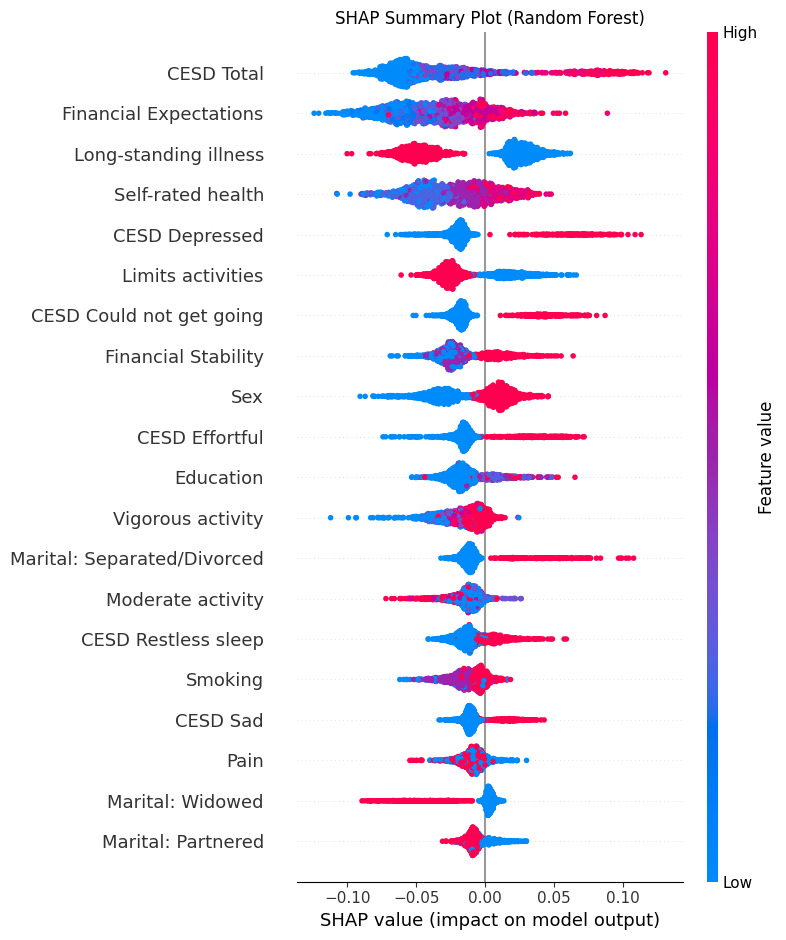

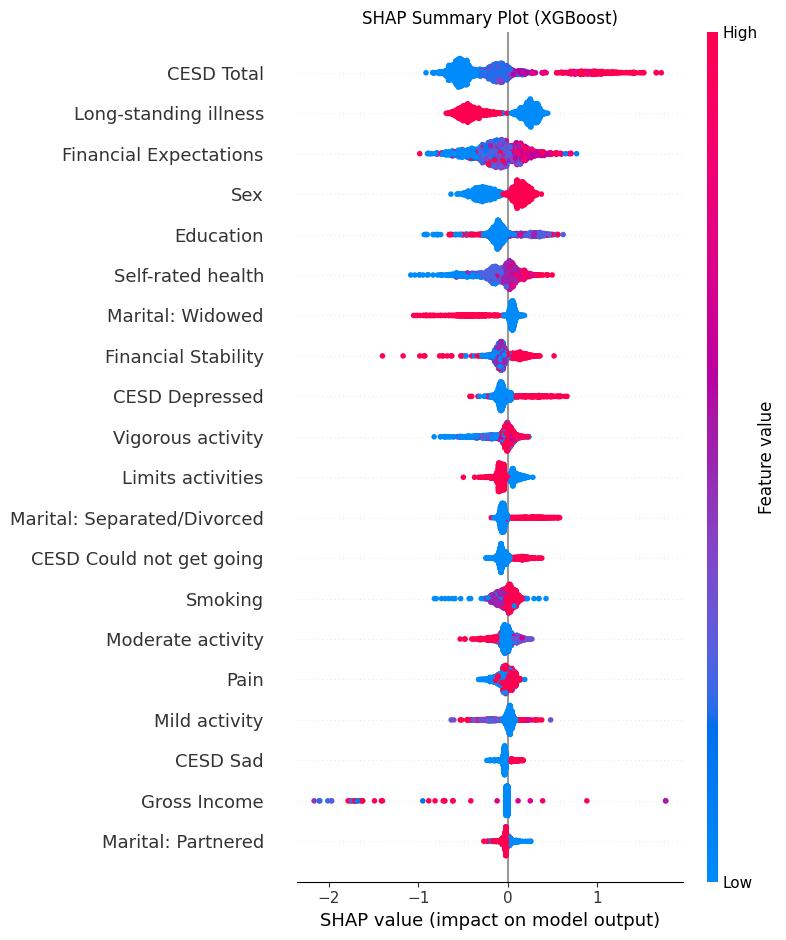

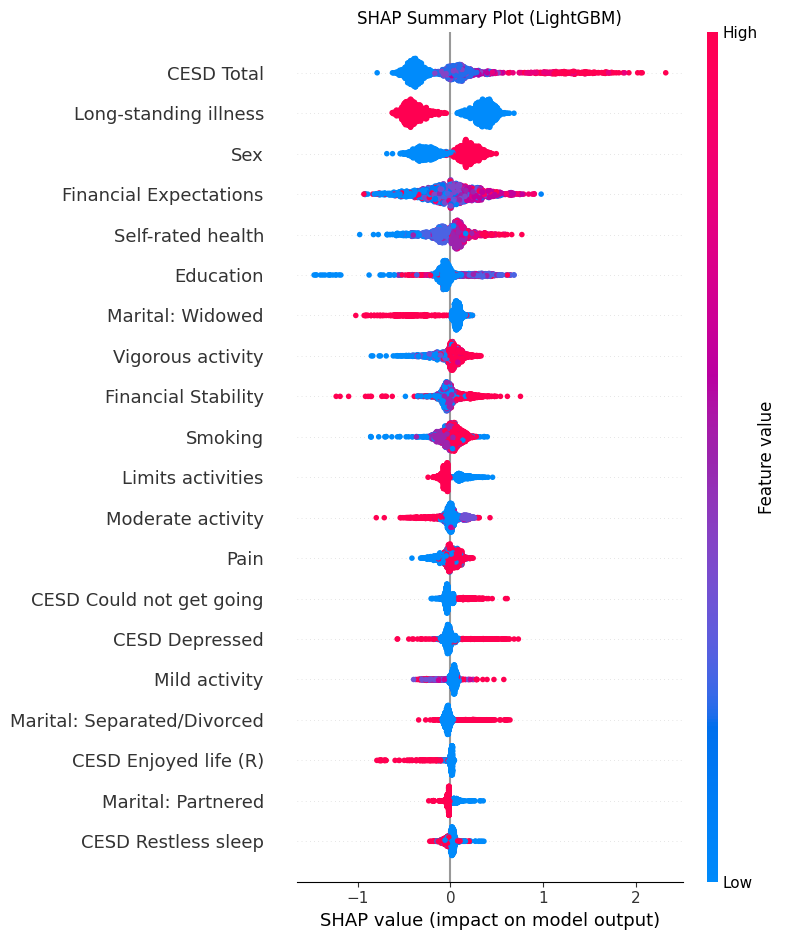

In [18]:
readable_names = {
    'DiSex':              'Sex',
    'marital_Partnered':  'Marital: Partnered',
    'marital_Single':     'Marital: Single',
    'marital_SepDivorced':'Marital: Separated/Divorced',
    'marital_Widowed':    'Marital: Widowed',
    'DiMaedu':            'Education',
    'Hehelf':             'Self-rated health',
    'Heill':              'Long-standing illness',
    'Helim':              'Limits activities',
    'HePain':             'Pain',
    'HeSmk':              'Smoking',
    'HeActa':             'Vigorous activity',
    'HeActb':             'Moderate activity',
    'HeActc':             'Mild activity',
    'PScedA_bin':         'CESD Depressed',
    'PScedB_bin':         'CESD Effortful',
    'PScedC_bin':         'CESD Restless sleep',
    'PScedD_bin':         'CESD Happy (R)',
    'PScedE_bin':         'CESD Lonely',
    'PScedF_bin':         'CESD Enjoyed life (R)',
    'PScedG_bin':         'CESD Sad',
    'PScedH_bin':         'CESD Could not get going',
    'cesd_total':         'CESD Total',
    'ExRSLF':             'Financial Expectations',
    'Iafcon':             'Financial Stability',
    'WpWlyy':             'Gross Income',
}

# ----- Random Forest -----
X_test_rf = pd.DataFrame(
    rf_pipeline.named_steps['imputer'].transform(X_test),
    columns=FEATURE_COLS
)

rf_explainer = shap.TreeExplainer(rf_pipeline.named_steps['model'])
rf_shap_values = rf_explainer.shap_values(X_test_rf)

feature_labels = [readable_names.get(col, col) for col in FEATURE_COLS]

shap.summary_plot(
    rf_shap_values[:, :, 1],
    X_test_rf,
    show=False,
    feature_names=feature_labels
)

plt.title('SHAP Summary Plot (Random Forest)')
plt.tight_layout()
plt.savefig('rf_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


# ----- XGBoost -----
X_test_xgb_df = pd.DataFrame(
    xgb_pipeline.named_steps['imputer'].transform(X_test),
    columns=FEATURE_COLS
)

xgb_explainer = shap.TreeExplainer(xgb_pipeline.named_steps['model'])
xgb_shap_values = xgb_explainer.shap_values(X_test_xgb_df)

shap.summary_plot(
    xgb_shap_values,
    X_test_xgb_df,
    show=False,
    feature_names=feature_labels
)

plt.title('SHAP Summary Plot (XGBoost)')
plt.tight_layout()
plt.savefig('xgb_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


# ----- LightGBM -----
X_test_lgbm_df = pd.DataFrame(
    lgbm_pipeline.named_steps['imputer'].transform(X_test),
    columns=FEATURE_COLS
)

lgbm_explainer = shap.TreeExplainer(lgbm_pipeline.named_steps['model'])
lgbm_shap_values = lgbm_explainer.shap_values(X_test_lgbm_df)

shap.summary_plot(
    lgbm_shap_values,
    X_test_lgbm_df,
    show=False,
    feature_names=feature_labels
)

plt.title('SHAP Summary Plot (LightGBM)')
plt.tight_layout()
plt.savefig('lgbm_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

These results show that CESD features are highly relevant. However it is not clinically useful to know that people who are depressed tend to stay depressed. So the chart is re-plotted without CESD features:

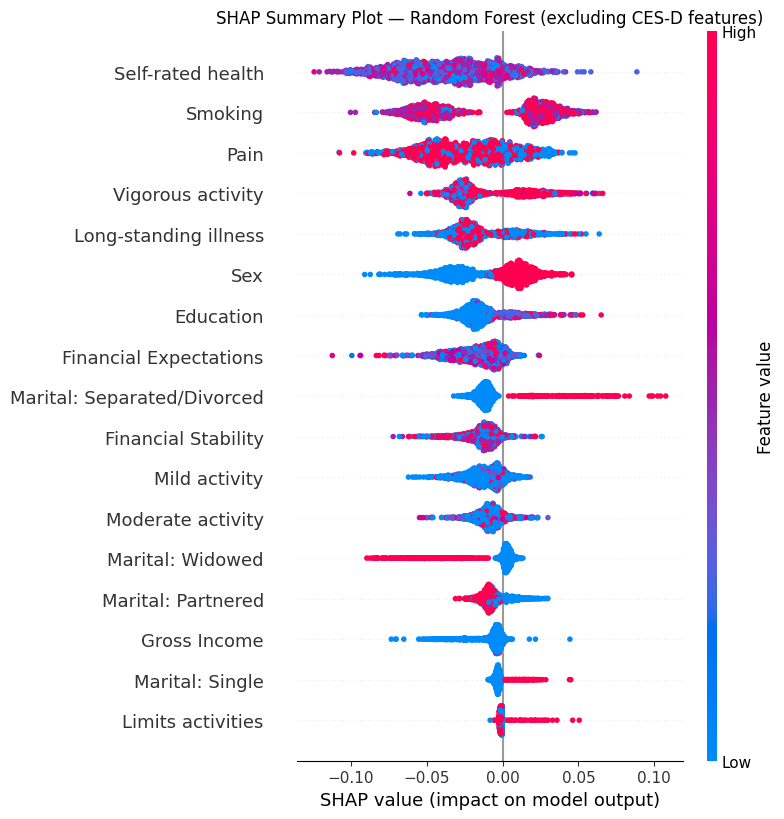

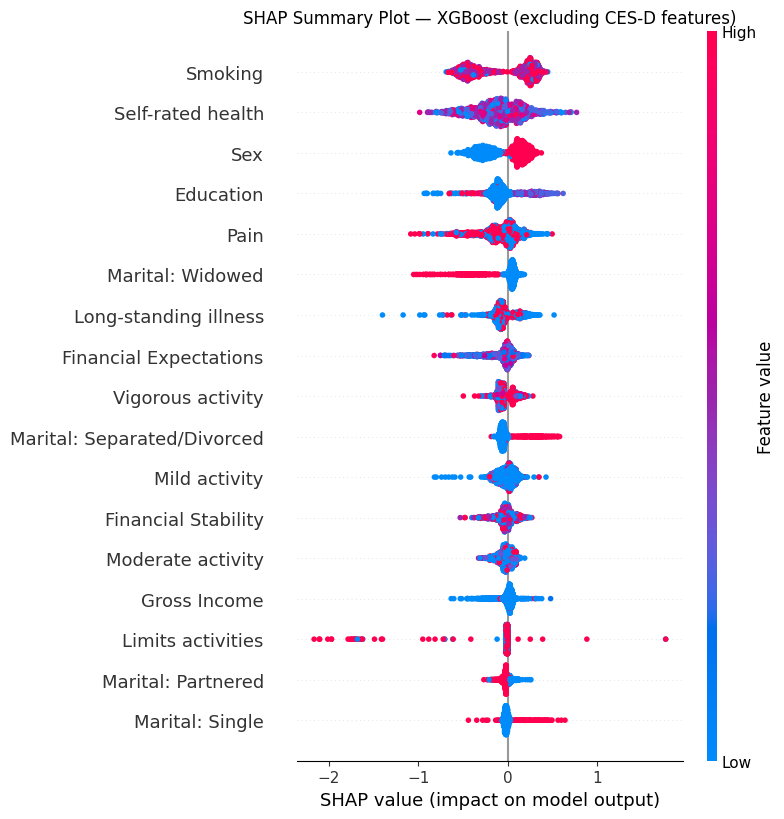

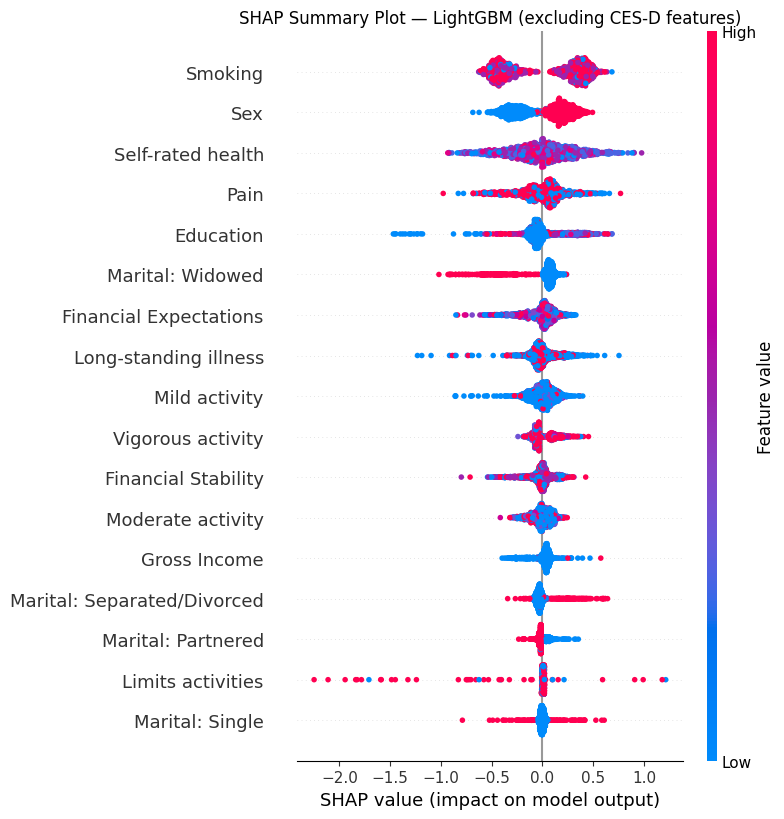

In [19]:

FEATURE_COLS_EXC_CESD = [
    'DiSex',
    'marital_Partnered', 'marital_Single', 'marital_SepDivorced', 'marital_Widowed',
    'DiMaedu',
    'Hehelf', 'Heill', 'Helim', 'HePain', 'HeSmk',
    'HeActa', 'HeActb', 'HeActc', 'ExRSLF', 'Iafcon', 'WpWlyy'
]

readable_names_exc_cesd = {
    'DiSex':              'Sex',
    'marital_Partnered':  'Marital: Partnered',
    'marital_Single':     'Marital: Single',
    'marital_SepDivorced':'Marital: Separated/Divorced',
    'marital_Widowed':    'Marital: Widowed',
    'DiMaedu':            'Education',
    'Hehelf':             'Self-rated health',
    'Heill':              'Long-standing illness',
    'Helim':              'Limits activities',
    'HePain':             'Pain',
    'HeSmk':              'Smoking',
    'HeActa':             'Vigorous activity',
    'HeActb':             'Moderate activity',
    'HeActc':             'Mild activity',
    'ExRSLF':             'Financial Expectations',
    'Iafcon':             'Financial Stability',
    'WpWlyy':             'Gross Income',
}

# Indices of non-CESD features within the full FEATURE_COLS list
non_cesd_idx = [i for i, col in enumerate(FEATURE_COLS) if col in FEATURE_COLS_EXC_CESD]
feature_labels_exc_cesd = [readable_names_exc_cesd[col] for col in FEATURE_COLS_EXC_CESD]

# ----- Random Forest -----
X_test_imp = pd.DataFrame(
    rf_pipeline.named_steps['imputer'].transform(X_test),
    columns=FEATURE_COLS
)

rf_explainer = shap.TreeExplainer(rf_pipeline.named_steps['model'])
rf_shap_values = rf_explainer.shap_values(X_test_imp)

shap.summary_plot(
    rf_shap_values[:, non_cesd_idx, 1],
    X_test_imp[FEATURE_COLS_EXC_CESD],
    show=False,
    feature_names=feature_labels_exc_cesd
)
plt.title('SHAP Summary Plot — Random Forest (excluding CES-D features)')
plt.tight_layout()
plt.savefig('rf_shap_summary_excluding_CESD.png', dpi=150, bbox_inches='tight')
plt.show()


# ----- XGBoost -----
X_test_imp_xgb = pd.DataFrame(
    xgb_pipeline.named_steps['imputer'].transform(X_test),
    columns=FEATURE_COLS
)

xgb_explainer = shap.TreeExplainer(xgb_pipeline.named_steps['model'])
xgb_shap_values = xgb_explainer.shap_values(X_test_imp_xgb)

shap.summary_plot(
    xgb_shap_values[:, non_cesd_idx],
    X_test_imp_xgb[FEATURE_COLS_EXC_CESD],
    show=False,
    feature_names=feature_labels_exc_cesd
)
plt.title('SHAP Summary Plot — XGBoost (excluding CES-D features)')
plt.tight_layout()
plt.savefig('xgb_shap_summary_excluding_CESD.png', dpi=150, bbox_inches='tight')
plt.show()

# ----- LightGBM -----
X_test_imp_lgbm = pd.DataFrame(
    lgbm_pipeline.named_steps['imputer'].transform(X_test),
    columns=FEATURE_COLS
)

lgbm_explainer = shap.TreeExplainer(lgbm_pipeline.named_steps['model'])
lgbm_shap_values = lgbm_explainer.shap_values(X_test_imp_lgbm)

shap.summary_plot(
    lgbm_shap_values[:, non_cesd_idx],
    X_test_imp_lgbm[FEATURE_COLS_EXC_CESD],
    show=False,
    feature_names=feature_labels_exc_cesd
)
plt.title('SHAP Summary Plot — LightGBM (excluding CES-D features)')
plt.tight_layout()
plt.savefig('lgbm_shap_summary_excluding_CESD.png', dpi=150, bbox_inches='tight')
plt.show()
